---
## ⚠️ IMPORTANT USAGE NOTES

### Changes from Original
This notebook has been modified to use different data sources for the multifidelity inputs. Make sure you:

1. **Have the required data files:**
   - `./data/ice/Antarctic_thickness_1993_2023.pkl` (ice thickness)
   - `./data/ice/Antarctic_SST_1993_2023.pkl` (SST data)
   - `./data/ice/Antarctic_years_1989_2024i.pkl` (original ice concentration data)

2. **Update the experiment configuration** (`ice_1.yaml` or similar):
   - No changes needed to the config file itself
   - The model will automatically adapt dimensions based on data shapes

3. **Run all cells in order:**
   - The notebook requires sequential execution
   - Data preprocessing steps build on each other

### Expected Dimensions
After preprocessing, you should see:
- `x1_train`: (n_train_days, n_pixels_region) - Ice thickness
- `x2_train`: (n_train_days, n_pixels_region) - SST
- `x3_train`: (n_train_days, n_sensors) - Sensors
- `y_train`: (n_train_days, n_pixels_region) - Target residuals

Where `n_pixels_region` depends on the region mask (typically ~2500-3000 pixels).

---

# Multifidelity Transformer - Ice Thickness & SST Version

**Modified from MF_Res_Val_Cal.ipynb**

## Key Changes

This notebook uses different low-fidelity data sources to provide auxiliary information to the multifidelity transformer:

### Data Sources
- **Level 1 (x1)**: **Ice Thickness** - Full spatial field from `Antarctic_thickness_1993_2023.pkl`
  - Original: Climatology spatial integral (1D scalar time series)
  - Modified: Full 2D ice thickness field, masked to target region
  - Shape: (n_days, n_pixels_region) where n_pixels_region matches target

- **Level 2 (x2)**: **SST (Sea Surface Temperature)** - from `Antarctic_SST_1993_2023.pkl`
  - Original: Local window climatology (small spatial region)
  - Modified: Full 2D SST field, masked to target region
  - Shape: (n_days, n_pixels_region) where n_pixels_region matches target

- **Level 3 (x3)**: **Sensor data** - Sparse sensor measurements (unchanged)
  - Shape: (n_days, n_sensors) where n_sensors = 128

### Target (y)
- Remains the same: **Residuals from DMD predictions** for sea ice concentration
- Shape: (n_days, n_pixels_region)

### Expected Benefits
- Ice thickness provides direct physical information about ice conditions
- SST provides oceanographic context that influences ice formation/melting
- Both provide richer spatial information compared to scalar or small-window data

In [1]:
#import libraries for multifidelity transformer
import numpy as np
from matplotlib import pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import LambdaLR
import matplotlib.pyplot as plt
import yaml
import wandb
import pandas as pd
from tqdm import tqdm

# Scientific computing
from scipy.optimize import minimize
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler, RobustScaler

# PyDMD imports for Dynamic Mode Decomposition
from pydmd import DMD, BOPDMD, FbDMD, MrDMD
from pydmd.plotter import plot_eigs, plot_summary, plot_modes_2D
from pydmd.preprocessing import hankel_preprocessing

# Data handling
import dill
import pickle

# System path for local modules
import sys
sys.path.append('./src/modules')

# Import utility functions from src/modules
from data_wrangle import thin_data, del_leap, get_days_before, window_mean, get_test_set, day_to_date, date_to_day
from dmd_routines import reshape_data2dmd, train_dmd, reshape_Psi2data, eval_dmd, eval_dmd_latent, bootstrap_train_dmd, eval_dmd_ensemble

# Jupyter widgets for interactive elements
from ipywidgets import interact, interactive, fixed
import ipywidgets as widgets

import matplotlib.pyplot as plt
from matplotlib.widgets import Button, Slider

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import LambdaLR
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Rectangle
import wandb
import warnings
warnings.filterwarnings("ignore")

# Import multifidelity modules
from multifidelity_transformer.utils.data import MultiFidelityDataset, compute_randomized_SVD
from multifidelity_transformer.models.models_experimental import MultifidelityTransformer
from multifidelity_transformer.utils.training import lr_schedule, run_epoch, model_eval, CustomMSE

# Set device
device = "cpu"
print(f"Using device: {device}")

Using device: cpu


/Users/giorgioaurina/Desktop/Cluster_Poli/Progressive-Multifidelity-Learning/./src/modules/data_wrangle.py:10: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


In [2]:
import torch
if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    x = torch.ones(1, device=mps_device)
    print (x)
else:
    print ("MPS device not found.")

tensor([1.], device='mps:0')


In [3]:
import torch
if torch.backends.mps.is_available():
    torch.mps.empty_cache()

In [4]:
def plot_data(data, mask=True, x=None, y=None, cmap='viridis', min_max=False):
    """
    Plot batch of shape (N_states, x, y)
    - If data is a list of arrays, create subplots (1, len(data))
    """
    # Handle x and y defaults
    if isinstance(data, list):
        N_states = data[0].shape[0]
    else:
        N_states = data.shape[0]
        
    if x is None: 
        x = np.arange(data[0].shape[2] if isinstance(data, list) else data.shape[2])
    if y is None: 
        y = np.arange(data[0].shape[1] if isinstance(data, list) else data.shape[1])
    
    def plot(i, BATCH_list, mask=True):
        num_plots = len(BATCH_list) if isinstance(BATCH_list, list) else 1
        
        fig, axes = plt.subplots(1, num_plots, figsize=(5 * num_plots, 5))
        if num_plots == 1:
            axes = [axes]  # make iterable
        
        for ax_idx, ax in enumerate(axes):
            BATCH = BATCH_list[ax_idx] if isinstance(BATCH_list, list) else BATCH_list
            ax.clear()
            ax.set(adjustable='box', aspect=1) 
            
            if min_max:
                cf = ax.contourf(
                    x, y, np.clip(np.where(~mask, BATCH[i, ...], np.nan), 0, 1),#x, y, np.where(~mask, BATCH[i, ...], np.nan), 
                    cmap=cmap, vmin=0., vmax=1.
                )
            else:
                cf = ax.contourf(
                    x, y, np.where(~mask, BATCH[i, ...], np.nan), 
                    cmap=cmap
                )
            ax.set_title(f'Data {ax_idx} (frame {i})') 
            
            # Link colorbar to cf
            cbar = plt.colorbar(cf, ax=ax)
            cbar.set_label('Value')
        
        plt.tight_layout()
        plt.show()
    
    # Slider for frame index
    i_widget = widgets.IntSlider(
        min=0, max=N_states - 1, step=1, value=0, 
        continuous_update=True, description='Frame'
    )
    
    # Fix data reference
    fixed_data = fixed(data) if isinstance(data, list) else fixed(data)
    
    # Create interactive widget
    w = interactive(
        plot, 
        i=i_widget, 
        BATCH_list=fixed(data), 
        mask=fixed(mask)
    )
    
    return w

'''def plot_data(data, mask = True, x = None, y = None):
    """
    plot batch of shape (N_states, x, y)
    """
    def plot(i, BATCH, mask = True):
        
        fig, ax = plt.subplots()
        ax.set(adjustable='box', aspect=1) 
        ax.contourf(x, y, np.where(~mask, BATCH[i, ...], np.nan) )
        

    if x is None: x = np.arange(data.shape[1])
    if y is None: y = np.arange(data.shape[0])

    i_widget = widgets.IntSlider(min=0, 
                                max=data.shape[0]-1, step=1, value=0, 
                                continuous_update=True, 
                                description = 'f_i(x,y)',
                                )

    w = interactive(plot, 
                    i = i_widget, 
                    BATCH = fixed(data), mask = fixed(mask))
    
    return w'''


'def plot_data(data, mask = True, x = None, y = None):\n    """\n    plot batch of shape (N_states, x, y)\n    """\n    def plot(i, BATCH, mask = True):\n        \n        fig, ax = plt.subplots()\n        ax.set(adjustable=\'box\', aspect=1) \n        ax.contourf(x, y, np.where(~mask, BATCH[i, ...], np.nan) )\n        \n\n    if x is None: x = np.arange(data.shape[1])\n    if y is None: y = np.arange(data.shape[0])\n\n    i_widget = widgets.IntSlider(min=0, \n                                max=data.shape[0]-1, step=1, value=0, \n                                continuous_update=True, \n                                description = \'f_i(x,y)\',\n                                )\n\n    w = interactive(plot, \n                    i = i_widget, \n                    BATCH = fixed(data), mask = fixed(mask))\n    \n    return w'

In [5]:
EVAL_INTERVAL = 300

In [6]:
# Read the parameters for the experiment
experiment_name = "ice"
experiment_number = 1
experiment = f"{experiment_name}_{experiment_number}"
parameters_path = f'./multifidelity_transformer/experiment_configurations/{experiment_name}/{experiment_number}.yaml'
with open(parameters_path, 'r') as file:
    parameters = yaml.safe_load(file)

In [7]:
parameters

{'experiment_name': 'J_new',
 'data': {'path': '/Users/giorgioaurina/Desktop/Paolo/Progressive-Multifidelity-Learning/data/ice/',
  'sequential_mask': False,
  'scaling': 'SV',
  'seq_len': 365,
  'seq_freq': 30,
  'dimensions': {'level_0': 'None',
   'level_1': 'None',
   'level_2': 'None',
   'output': 'None',
   'parameters_dim': 1}},
 'model': {'checkpoints_path': '/checkpoints',
  'load_model': False,
  'save_model': True,
  'embedding_dim': 64,
  'n_heads': 2,
  'mask_embeddings': False,
  'n_transformer_blocks': 1,
  'dropout': 0.2},
 'logging': {'wandb': False, 'gradients': False, 'save_model': True},
 'training': {'epochs': 300,
  'batch_size': 64,
  'optim_params': {'learning_rate': 0.1,
   'warmup': 800,
   'betas': [0.9, 0.98],
   'eps': '1e-9',
   'weight_decay': '1e-4'}}}

In [8]:
# wandb logging
if parameters["logging"]["wandb"]:
    wandb.login()
    wandb_run = wandb.init(
        project="MultifidelityTransformer",
        config=parameters,
        name=parameters["experiment_name"],
        reinit=True,
    )
else:
    wandb_run = None

## 0) OPEN DATA & PREPROCESSING

In [9]:
# Esempio di caricamento futuro
with open('./data/ice/Antarctic_SST_1993_2023.pkl', 'rb') as f:
    sst_data_, sst_years_ = dill.load(f)

In [10]:
# Esempio di caricamento futuro
with open('./data/ice/Antarctic_thickness_1993_2023.pkl', 'rb') as f:
    thickness_data_, thickness_years_ = dill.load(f)

# Ora thickness_data è una lista compatibile col tuo codice
# Esempio: w0 = plot_data(thickness_data[0], mask=mask_land_, ...)

In [11]:
with open('/Users/giorgioaurina/Desktop/Paolo/Progressive-Multifidelity-Learning/data/ice/Antarctic_years_1989_2024i.pkl', 'rb') as f:
    mask_land_, mask_ice_, data_, data_mean_month_, data_mean_week_, x_, y_ = dill.load(f)

In [12]:
len(data_)

36

In [13]:
thin = 2
window = 1
data, data_mean_month, data_mean_week, x, y, mask_ice, mask_land = \
    thin_data(thin, data_, data_mean_month_, data_mean_week_, x_, y_, mask_ice_, mask_land_)

data = del_leap(data)
del data_, data_mean_month_, data_mean_week_
ny, nx = data[0].shape[1:]

mask_ice_.shape, mask_ice.shape

(365, 216, 216)
(12, 216, 216)
(52, 216, 216)


  0%|          | 0/36 [00:00<?, ?it/s]

((432, 432), (216, 216))

In [14]:
# Apply the same thinning and del_leap to thickness and SST data
# thin_data returns a list of processed arguments, so unpack with [0]
thickness_data = thin_data(thin, thickness_data_)[0]
sst_data = thin_data(thin, sst_data_)[0]

# Remove leap days (del_leap returns the processed list directly)
thickness_data = del_leap(thickness_data)
sst_data = del_leap(sst_data)

print(f"After preprocessing:")
print(f"  thickness_data: {len(thickness_data)} years")
print(f"  sst_data: {len(sst_data)} years")
print(f"  data: {len(data)} years")
if len(thickness_data) > 0:
    print(f"  thickness_data[0].shape: {thickness_data[0].shape}")
if len(sst_data) > 0:
    print(f"  sst_data[0].shape: {sst_data[0].shape}")

(365, 216, 216)
(365, 216, 216)


  0%|          | 0/31 [00:00<?, ?it/s]

  0%|          | 0/31 [00:00<?, ?it/s]

After preprocessing:
  thickness_data: 31 years
  sst_data: 31 years
  data: 36 years
  thickness_data[0].shape: (365, 216, 216)
  sst_data[0].shape: (365, 216, 216)


- `data_` is a list of 36 years where each one has dimension (n_day, nx, ny), where n_day = 365, nx=ny=432
- `mask_land_` is a boolean mask to indicate where there is land or water
- `data_mean_month_` and `data_mean_week_` have monthly and weekly time frequency (instead of daily)

`thin_data` reduce spatial dimensionality to the degrees of freedom where we do not have land\

In [15]:
len(data)

36

In [16]:
data = data[4:-1]

In [17]:
len(thickness_data)

31

In [18]:
w0 = plot_data([thickness_data[0], sst_data[0], data[0]], 
              mask = mask_land, 
              x = x, 
              y = y)

display(w0)

interactive(children=(IntSlider(value=0, description='Frame', max=364), Output()), _dom_classes=('widget-inter…

In [19]:
# Robust TRAIN/TEST SPLIT by whole years (avoid flatten/reshape issues)
from collections import Counter

# Inspect raw year shapes and keep the dominant (most common) shape
year_shapes = [tuple(np.asarray(y).shape) for y in data]
shape_counts = Counter(year_shapes)
if not shape_counts:
    raise ValueError("No yearly arrays found in 'data'.")

target_shape, target_count = shape_counts.most_common(1)[0]
print(f"Year shapes (top): {target_shape} × {target_count} years")

# Filter years to the dominant consistent shape
filtered_years = [np.asarray(y) for y in data if tuple(np.asarray(y).shape) == target_shape]

# Sanity checks on target shape
if len(target_shape) != 3:
    raise ValueError(f"Expected each year as (days, nx, ny); got {target_shape}")
if target_shape[0] != 365:
    raise ValueError(f"Expected 365 days per year after preprocessing; got {target_shape[0]}")

years_available = len(filtered_years)
print(f"Years available (filtered to consistent shape): {years_available}")

# Desired split
DESIRED_TRAIN = 20
DESIRED_VAL = 6
DESIRED_TEST = 5

# Validate and adjust if needed
if DESIRED_TRAIN > years_available:
    raise ValueError(f"Requested {DESIRED_TRAIN} training years but only {years_available} available.")

max_test = years_available - DESIRED_TRAIN
if DESIRED_TEST > max_test:
    print(f"Warning: Only {max_test} test years available; using that instead of {DESIRED_TEST}.")
    DESIRED_TEST = max_test

n_year_train = DESIRED_TRAIN
n_year_val = DESIRED_VAL
n_year_test = DESIRED_TEST
n_year_tot = n_year_train + n_year_val + n_year_test

# Stack to (Y, 365, nx, ny)
data_years = np.stack(filtered_years, axis=0)

# Perform the split by year index
data_train = data_years[:n_year_train]
data_val   = data_years[n_year_train:n_year_train + n_year_val]
data_test  = data_years[n_year_train + n_year_val:]

# Derive convenience vars
ny, nx = data_train.shape[2], data_train.shape[3]

# Combine for downstream steps (train+val  +test)
data_tot = np.concatenate((data_train, data_val, data_test), axis=0)

print("Split summary → train:", data_train.shape, "val:", data_val.shape, "test:", data_test.shape, "total:", data_tot.shape)

Year shapes (top): (365, 216, 216) × 31 years
Years available (filtered to consistent shape): 31
Split summary → train: (20, 365, 216, 216) val: (6, 365, 216, 216) test: (5, 365, 216, 216) total: (31, 365, 216, 216)


In [20]:
# Confirm shapes after robust split
print('data_tot shape:', data_tot.shape)
print('train/val/test years:', n_year_train, n_year_val, n_year_test)

data_tot shape: (31, 365, 216, 216)
train/val/test years: 20 6 5


In [21]:
data_tot.shape

(31, 365, 216, 216)

In [22]:
w0 = plot_data(data_train[14], 
              mask = mask_land, 
              x = x, 
              y = y)

display(w0)

interactive(children=(IntSlider(value=0, description='Frame', max=364), Output()), _dom_classes=('widget-inter…

## 1c) DMD offline predictions

In [23]:
import dill

load_path = './checkpoints/dmd_fits_all_years/dmd_forecasts_rank5_bootstrap50_years2-34.pkl'

with open(load_path, 'rb') as f:
    dmd_filtered_results = dill.load(f) 

years = dmd_filtered_results['years']
y_pred_mean_all = dmd_filtered_results['y_pred_mean']
y_pred_std_all = dmd_filtered_results['y_pred_std']

In [24]:
y_pred_mean_all = y_pred_mean_all[2:]
y_pred_std_all = y_pred_std_all[2:]
years = years[2:]

In [25]:
y_pred_mean_all.shape

(31, 365, 216, 216)

## 2) LOW FIDELITY DATA - MODIFIED VERSION

### Level 1 (x1): Ice Thickness
Using full spatial ice thickness data from Antarctic_thickness_1993_2023.pkl

In [26]:
# Match the train/val/test split
thickness_tot = np.array(thickness_data[:n_year_tot])  # Use same number of years as data_tot
thickness_train = thickness_tot[:n_year_train]
thickness_val = thickness_tot[n_year_train:n_year_train + n_year_val]
thickness_test = thickness_tot[n_year_train + n_year_val:n_year_train + n_year_val + n_year_test]

x1_train = thickness_train
x1_val = thickness_val
x1_test = thickness_test

print(f"Ice Thickness data shapes: train={x1_train.shape}, val={x1_val.shape}, test={x1_test.shape}")

Ice Thickness data shapes: train=(20, 365, 216, 216), val=(6, 365, 216, 216), test=(5, 365, 216, 216)


### Level 2 (x2): SST Data - MODIFIED
Using Sea Surface Temperature data from Antarctic_SST_1993_2023.pkl instead of local window climatology

In [27]:
# Match the train/val/test split
sst_tot = np.array(sst_data[:n_year_tot])  # Use same number of years as data_tot
sst_train = sst_tot[:n_year_train]
sst_val = sst_tot[n_year_train:n_year_train + n_year_val]
sst_test = sst_tot[n_year_train + n_year_val:n_year_train + n_year_val + n_year_test]

x2_train = sst_train
x2_val = sst_val
x2_test = sst_test

print(f"Ice Thickness data shapes: train={x2_train.shape}, val={x2_val.shape}, test={x2_test.shape}")

Ice Thickness data shapes: train=(20, 365, 216, 216), val=(6, 365, 216, 216), test=(5, 365, 216, 216)


## 2c) Sensors

Original ice mask has 10923 valid pixels
Probabilistic ice mask has 5164 valid pixels
Reduction factor: 0.473


Text(0.5, 1.0, 'Sample Ice Concentration')

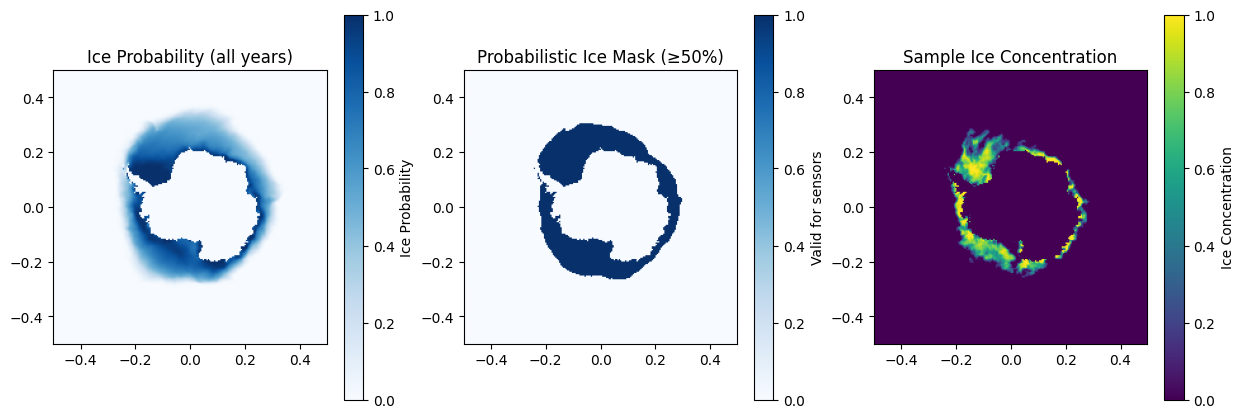

In [28]:
# Create a probabilistic ice mask: regions with ice in at least 50% of years
ice_probability_threshold = 0.5  # 50% of years must have ice
min_ice_concentration = 0.1  # Minimum concentration to consider as "ice present"

# Calculate probability of ice presence for each pixel across all years and days
ice_presence = (data_tot > min_ice_concentration).astype(float)  # Shape: (n_years, n_days, nx, ny)
ice_probability = ice_presence.mean(axis=(0, 1))  # Average over years and days

# Create mask for regions with sufficient ice probability
mask_ice_probable = (ice_probability >= ice_probability_threshold) & mask_ice

print(f"Original ice mask has {np.sum(mask_ice)} valid pixels")
print(f"Probabilistic ice mask has {np.sum(mask_ice_probable)} valid pixels")
print(f"Reduction factor: {np.sum(mask_ice_probable) / np.sum(mask_ice):.3f}")

# Visualize the probabilistic mask
plt.figure(figsize=(15, 5))

plt.subplot(131)
plt.imshow(ice_probability, origin='lower', cmap='Blues', extent=[x.min(), x.max(), y.min(), y.max()], vmin=0, vmax=1)
plt.colorbar(label='Ice Probability')
plt.title('Ice Probability (all years)')

plt.subplot(132)
plt.imshow(mask_ice_probable, origin='lower', cmap='Blues', extent=[x.min(), x.max(), y.min(), y.max()])
plt.colorbar(label='Valid for sensors')
plt.title('Probabilistic Ice Mask (≥50%)')

plt.subplot(133)
plt.imshow(data_tot[0][0], origin='lower', cmap='viridis', extent=[x.min(), x.max(), y.min(), y.max()], vmin=0, vmax=1)
plt.colorbar(label='Ice Concentration')
plt.title('Sample Ice Concentration')

Available locations for sensors: 5164
Sensor data shape: (31, 365, 128)
Number of sensors actually placed: 128


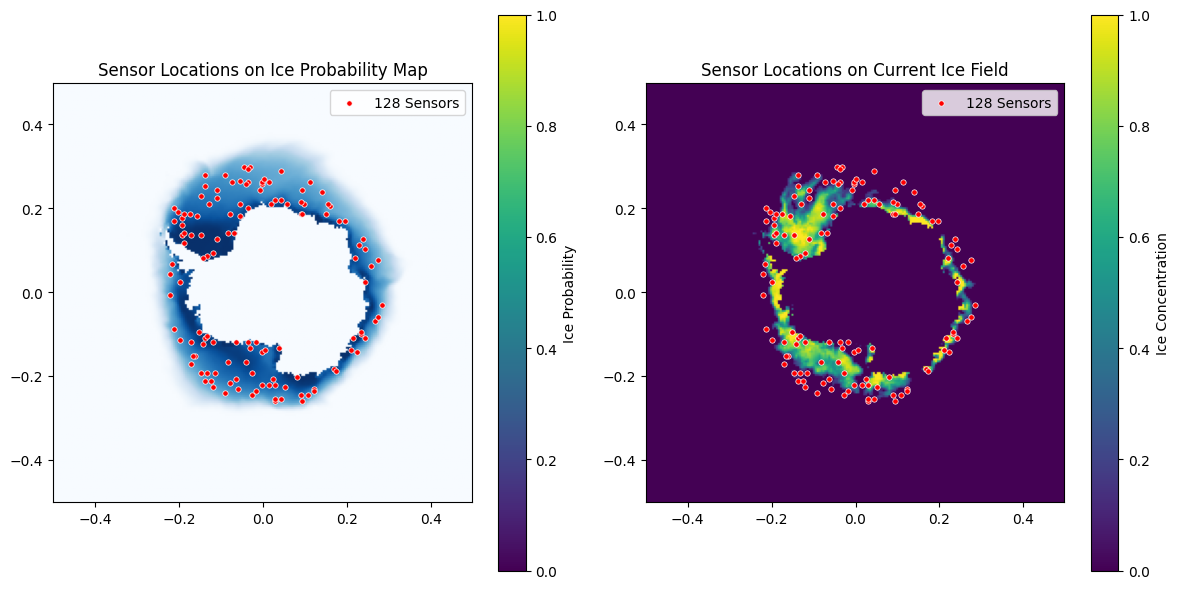

In [29]:
n_sensors = 128

# Extract indices where probabilistic ice mask is True (regions with ice ≥50% of time)
mask_ice_probable_idxs = np.argwhere(mask_ice_probable)

print(f"Available locations for sensors: {len(mask_ice_probable_idxs)}")

# Randomly choose n_sensors from the probabilistically valid locations
np.random.seed(0)  # For reproducibility
if len(mask_ice_probable_idxs) >= n_sensors:
    sensor_idxs = mask_ice_probable_idxs[np.random.choice(mask_ice_probable_idxs.shape[0], n_sensors, replace=False)]
else:
    print(f"Warning: Only {len(mask_ice_probable_idxs)} valid locations available, using all of them")
    sensor_idxs = mask_ice_probable_idxs
    n_sensors = len(sensor_idxs)

# Create sensor_mask
sensor_mask = np.zeros_like(mask_ice, dtype=bool)
sensor_mask[tuple(sensor_idxs.T)] = True

# Plot sensor locations with probabilistic context
plt.figure(figsize=(12,6))

plt.subplot(121)
# Show ice probability map with sensor locations
plt.imshow(ice_probability, origin='lower', cmap='Blues', extent=[x.min(), x.max(), y.min(), y.max()], vmin=0, vmax=1)
plt.scatter(x[sensor_idxs[:,1]], y[sensor_idxs[:,0]], color='red', s=15, label=f'{n_sensors} Sensors', edgecolors='white', linewidth=0.5)
plt.colorbar(label='Ice Probability')
plt.title('Sensor Locations on Ice Probability Map')
plt.legend()

plt.subplot(122)
# Show current ice concentration with sensor locations
plt.imshow(data_tot[0][0], origin='lower', cmap='viridis', extent=[x.min(), x.max(), y.min(), y.max()], vmin=0, vmax=1)
plt.scatter(x[sensor_idxs[:,1]], y[sensor_idxs[:,0]], color='red', s=15, label=f'{n_sensors} Sensors', edgecolors='white', linewidth=0.5)
plt.colorbar(label='Ice Concentration')
plt.title('Sensor Locations on Current Ice Field')
plt.legend()

plt.tight_layout()

clim_data_sensors = data_tot[:, :, sensor_mask]
print(f"Sensor data shape: {clim_data_sensors.shape}")
print(f"Number of sensors actually placed: {n_sensors}")

Text(0, 0.5, 'Sea Ice Concentration')

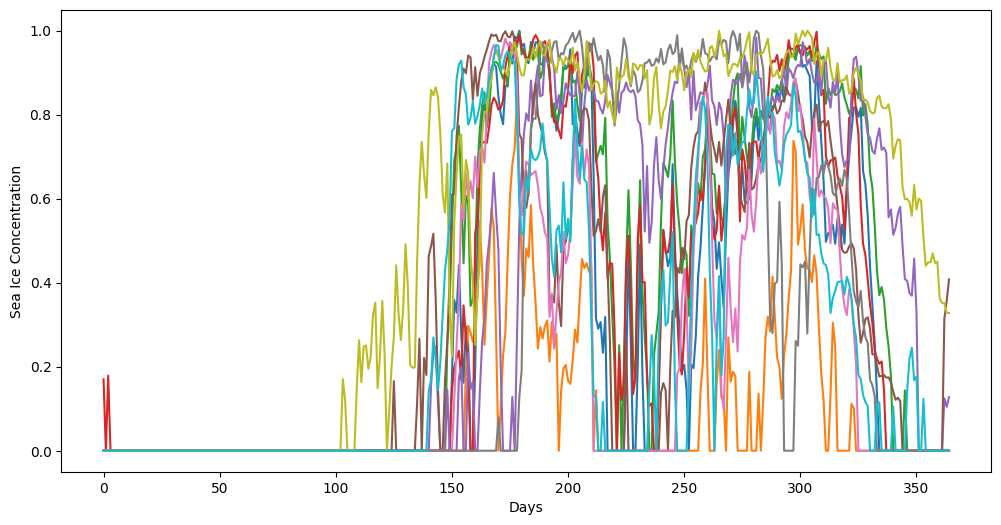

In [30]:
# Show some of the trajectories in the region for the first year
plt.figure(figsize=(12,6))
plt.plot(clim_data_sensors[0, :, :10])
plt.xlabel('Days')
plt.ylabel('Sea Ice Concentration') 

In [31]:
n_year_tot

31

In [32]:
# Keep x3 (sensors) from the original climatology data
x3_train, x3_val, x3_test = clim_data_sensors[:n_year_train], clim_data_sensors[n_year_train:(n_year_train+n_year_val)], clim_data_sensors[(n_year_train+n_year_val):]

print(f"SST (x2) data shapes: train={x2_train.shape}, val={x2_val.shape}, test={x2_test.shape}")
print(f"Sensor (x3) data shapes: train={x3_train.shape}, val={x3_val.shape}, test={x3_test.shape}")

SST (x2) data shapes: train=(20, 365, 216, 216), val=(6, 365, 216, 216), test=(5, 365, 216, 216)
Sensor (x3) data shapes: train=(20, 365, 128), val=(6, 365, 128), test=(5, 365, 128)


In [33]:
"""# Apply region mask to SST and thickness data to match target dimensions
# We still need to extract the same region for x1 and x2 to match the target y dimensions

# For thickness (x1): Apply region_mask
x1_train_region = x1_train[:, region_mask]  # (n_train_days, n_pixels_region)
x1_val_region = x1_val[:, region_mask]
x1_test_region = x1_test[:, region_mask]

# For SST (x2): Reshape first, then apply region_mask
x2_train_flat = x2_train.reshape(-1, *x2_train.shape[2:])  # (n_train_days, nx, ny)
x2_val_flat = x2_val.reshape(-1, *x2_val.shape[2:])
x2_test_flat = x2_test.reshape(-1, *x2_test.shape[2:])

x2_train_region = x2_train_flat[:, region_mask]  # (n_train_days, n_pixels_region)
x2_val_region = x2_val_flat[:, region_mask]
x2_test_region = x2_test_flat[:, region_mask]

# Update x1 and x2 to the region-masked versions
x1_train, x1_val, x1_test = x1_train_region, x1_val_region, x1_test_region
x2_train, x2_val, x2_test = x2_train_region, x2_val_region, x2_test_region

print(f"\\nAfter applying region mask:")
print(f"Thickness (x1) - train: {x1_train.shape}, val: {x1_val.shape}, test: {x1_test.shape}")
print(f"SST (x2) - train: {x2_train.shape}, val: {x2_val.shape}, test: {x2_test.shape}")
print(f"Sensors (x3) - train: {x3_train.shape}, val: {x3_val.shape}, test: {x3_test.shape}")"""

'# Apply region mask to SST and thickness data to match target dimensions\n# We still need to extract the same region for x1 and x2 to match the target y dimensions\n\n# For thickness (x1): Apply region_mask\nx1_train_region = x1_train[:, region_mask]  # (n_train_days, n_pixels_region)\nx1_val_region = x1_val[:, region_mask]\nx1_test_region = x1_test[:, region_mask]\n\n# For SST (x2): Reshape first, then apply region_mask\nx2_train_flat = x2_train.reshape(-1, *x2_train.shape[2:])  # (n_train_days, nx, ny)\nx2_val_flat = x2_val.reshape(-1, *x2_val.shape[2:])\nx2_test_flat = x2_test.reshape(-1, *x2_test.shape[2:])\n\nx2_train_region = x2_train_flat[:, region_mask]  # (n_train_days, n_pixels_region)\nx2_val_region = x2_val_flat[:, region_mask]\nx2_test_region = x2_test_flat[:, region_mask]\n\n# Update x1 and x2 to the region-masked versions\nx1_train, x1_val, x1_test = x1_train_region, x1_val_region, x1_test_region\nx2_train, x2_val, x2_test = x2_train_region, x2_val_region, x2_test_regio

### Summary of Multifidelity Data Sources

**Original version used:**
- Level 1: Climatology spatial integral (1D time series)
- Level 2: Local window climatology (small spatial region)
- Level 3: Sparse sensors

**Modified version uses:**
- **Level 1 (x1)**: Ice Thickness - Full spatial field, then masked to target region
- **Level 2 (x2)**: SST - Sea Surface Temperature, full spatial field, then masked to target region
- **Level 3 (x3)**: Sensor data - Unchanged (sparse sensor measurements)

All three levels are now masked to the same region as the target (y) for consistency.

In [34]:
y_pred_mean_all.shape

(31, 365, 216, 216)

In [35]:
years = years - 4

DMD predictions shape: (31, 365, 216, 216)
True data shape: (31, 365, 216, 216)
Residuals shape: (31, 365, 216, 216)

Residual statistics:
  Mean: -0.000556
  Std: 0.092805
  Min: -1.000000
  Max: 1.000000


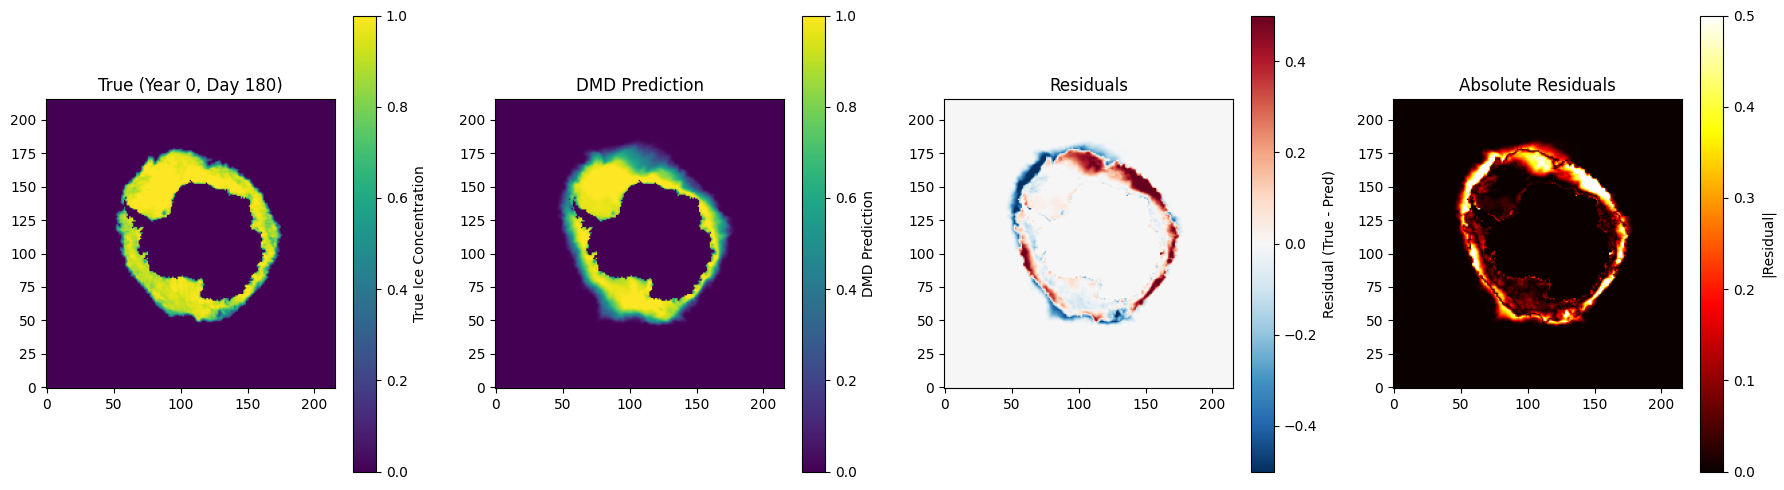


Residuals train shape: (20, 365, 216, 216)
Residuals val shape: (6, 365, 216, 216)
Residuals test shape: (5, 365, 216, 216)


In [36]:
# Generate residuals between DMD predictions and true data
# DMD predictions are in y_pred_mean_all with shape (34, 365, ny, nx)
# True data for those years is in data (the original filtered list)

# First, align the years: DMD was trained on years 3-35 (indices 2-34 in Python)
# So we need the corresponding true data
y_dmd_pred = y_pred_mean_all  # Shape: (33, 365, 216, 216)

# Clamp all values in y_dmd_pred greater than 1 to 1
y_dmd_pred = np.clip(y_dmd_pred, 0, 1)

# Get true data for years 3-35 (same years DMD was trained on)
y_true = np.array([data[year] for year in years])  # Shape: (33, 365, 216, 216)

# Compute residuals (error = true - predicted)
y_dmd_residuals = y_true - y_dmd_pred

print(f"DMD predictions shape: {y_dmd_pred.shape}")
print(f"True data shape: {y_true.shape}")
print(f"Residuals shape: {y_dmd_residuals.shape}")

# Statistics on residuals
print(f"\nResidual statistics:")
print(f"  Mean: {y_dmd_residuals.mean():.6f}")
print(f"  Std: {y_dmd_residuals.std():.6f}")
print(f"  Min: {y_dmd_residuals.min():.6f}")
print(f"  Max: {y_dmd_residuals.max():.6f}")

# Visualize residuals for a specific year and day
test_year_idx = 0
test_day = 180

plt.figure(figsize=(18, 5))

plt.subplot(141)
plt.imshow(y_true[test_year_idx, test_day], origin='lower', cmap='viridis', vmin=0, vmax=1)
plt.colorbar(label='True Ice Concentration')
plt.title(f'True (Year {years[test_year_idx]}, Day {test_day})')

plt.subplot(142)
plt.imshow(y_dmd_pred[test_year_idx, test_day], origin='lower', cmap='viridis', vmin=0, vmax=1)
plt.colorbar(label='DMD Prediction')
plt.title(f'DMD Prediction')

plt.subplot(143)
plt.imshow(y_dmd_residuals[test_year_idx, test_day], origin='lower', cmap='RdBu_r', vmin=-0.5, vmax=0.5)
plt.colorbar(label='Residual (True - Pred)')
plt.title(f'Residuals')

plt.subplot(144)
plt.imshow(np.abs(y_dmd_residuals[test_year_idx, test_day]), origin='lower', cmap='hot', vmin=0, vmax=0.5)
plt.colorbar(label='|Residual|')
plt.title(f'Absolute Residuals')

plt.tight_layout()
plt.show()

# Now split residuals into train/test following the same split as before
# Use the same split: first 22 years for train, last 11 for test
residuals_train = y_dmd_residuals[:n_year_train]  # Shape: (22, 365, 216, 216)
resideuals_val = y_dmd_residuals[n_year_train:n_year_train + n_year_val]  # Shape: (6, 365, 216, 216)
residuals_test = y_dmd_residuals[n_year_train+n_year_val:]  # Shape: (11, 365, 216, 216)

print(f"\nResiduals train shape: {residuals_train.shape}")
print(f"Residuals val shape: {resideuals_val.shape}")
print(f"Residuals test shape: {residuals_test.shape}")

In [37]:
y_train = residuals_train
y_val = resideuals_val
y_test = residuals_test

In [38]:
np.min(y_train[1]), np.max(y_train[5])
#np.min(y_test[0]), np.max(y_test[0])

(-0.9497007617565858, 0.9596309472389541)

sembra davvero tanto errore, sospetto giorni diversi

In [39]:
np.min(y_true[0]), np.max(y_true[0])

(0.0, 1.0)

In [40]:
np.min(y_dmd_pred[0]), np.max(y_dmd_pred[0])

(0.0, 1.0)

In [41]:
y_train.mean(), y_train.std()

(-6.498467471916964e-05, 0.09473863291959315)

In [42]:
y_train = (y_train - y_train.mean())/y_train.std()

In [43]:
y_val.mean(), y_val.std()

(-0.0010642070867538304, 0.09289156935780983)

In [44]:
y_val = (y_val - y_train.mean())/y_train.std()

In [45]:
y_test.mean(), y_test.std()

(-0.0019080957546780313, 0.08450007969262947)

In [46]:
"""N_dof = nx * ny
n_years_train = y_train.shape[0]
n_years_val = y_val.shape[0]
n_years_test = y_test.shape[0]

# Reshape training, and test data for POD
y_train_pod = y_train.reshape(-1, *y_train.shape[2:])
y_train_pod = np.reshape(y_train_pod.T, (N_dof, -1), 'F')

y_val_pod = y_val.reshape(-1, *y_val.shape[2:])
y_val_pod = np.reshape(y_val_pod.T, (N_dof, -1), 'F')

y_test_pod = y_test.reshape(-1, *y_test.shape[2:])
y_test_pod = np.reshape(y_test_pod.T, (N_dof, -1), 'F')

print(f"POD data shapes: train{y_train_pod.shape}, val{y_val_pod.shape}, test{y_test_pod.shape}")

#POD on training data ONLY (no data leakage)
n_POD = 64
U, S = compute_randomized_SVD(y_train_pod, n_POD, N_dof, 1)

plt.figure(figsize = (10,4))
plt.suptitle(f'POD modes: {n_POD})')
plt.subplot(121)
plt.plot(S,'*-')
plt.axvline(x = n_POD-1)
plt.yscale('log')
plt.xlabel('# bases')

plt.subplot(122)
plt.plot(np.cumsum(S)/np.sum(S),'*-')
plt.axvline(x = n_POD-1)
plt.xlabel('# bases')
plt.show()

print("Plot the POD modes")
w0 = plot_data(U.T.reshape(-1, nx, ny),
        mask = mask_land, 
        x = x, 
        y = y)

display(w0)

#############################################################
#POTREBBE ESSERE UN PROBLEMA, FORSE FARE SVD SU TRAIN + VAL

# Project ALL data onto the POD basis (fitted on training data only)
data_train = np.dot(y_train_pod.T, U)
data_test = np.dot(y_test_pod.T, U)

#Plot POD coefficients
print("Plot the temporal POD coefficients")
fig, ax = plt.subplots(3, 3, figsize=(15, 15))
for i in range(9):
        ax = fig.add_subplot(331 + i)
        plt.plot(data_train[:, i], label='Train')
        ax.title.set_text('POM ' + str(i+1))
        plt.xlabel('t')
        plt.legend()
plt.show()

# Create reduced representations for all three splits
y_train_reduced = data_train.reshape(n_years_train, -1, n_POD)
y_val_reduced = data_val.reshape(n_years_val, -1, n_POD)
y_test_reduced = data_test.reshape(n_years_test, -1, n_POD)

print(f"Reduced data shapes: train{y_train_reduced.shape}, val{y_val_reduced.shape}, test{y_test_reduced.shape}")"""

'N_dof = nx * ny\nn_years_train = y_train.shape[0]\nn_years_val = y_val.shape[0]\nn_years_test = y_test.shape[0]\n\n# Reshape training, and test data for POD\ny_train_pod = y_train.reshape(-1, *y_train.shape[2:])\ny_train_pod = np.reshape(y_train_pod.T, (N_dof, -1), \'F\')\n\ny_val_pod = y_val.reshape(-1, *y_val.shape[2:])\ny_val_pod = np.reshape(y_val_pod.T, (N_dof, -1), \'F\')\n\ny_test_pod = y_test.reshape(-1, *y_test.shape[2:])\ny_test_pod = np.reshape(y_test_pod.T, (N_dof, -1), \'F\')\n\nprint(f"POD data shapes: train{y_train_pod.shape}, val{y_val_pod.shape}, test{y_test_pod.shape}")\n\n#POD on training data ONLY (no data leakage)\nn_POD = 64\nU, S = compute_randomized_SVD(y_train_pod, n_POD, N_dof, 1)\n\nplt.figure(figsize = (10,4))\nplt.suptitle(f\'POD modes: {n_POD})\')\nplt.subplot(121)\nplt.plot(S,\'*-\')\nplt.axvline(x = n_POD-1)\nplt.yscale(\'log\')\nplt.xlabel(\'# bases\')\n\nplt.subplot(122)\nplt.plot(np.cumsum(S)/np.sum(S),\'*-\')\nplt.axvline(x = n_POD-1)\nplt.xlabel(\'

In [47]:
#U.shape

## NO POD, USARE FINESTRE DI DATI PIU PICCOLE

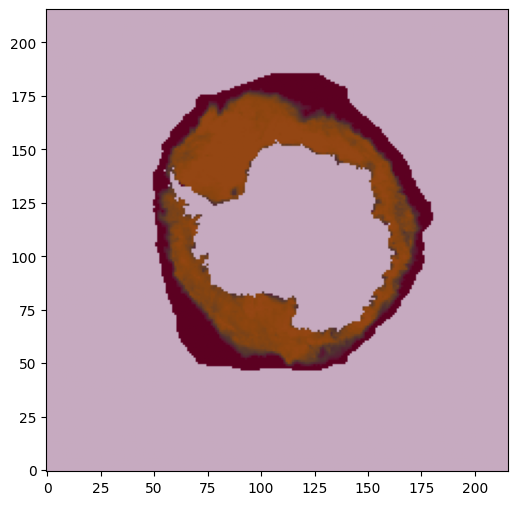

Shape of extracted region: (20, 365, 8528)


In [48]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# 1. Define Center and Radius (instead of min/max bounds)
center_x, center_y = 0.01, 0.025  # Change these to your desired center
radius1 = 0.2           # Change this to your desired radius
radius2 = 0.3        # Change this to your desired radius

# 2. Create the Radius Mask using broadcasting
# (x[None, :] makes x a row vector, y[:, None] makes y a column vector)
# This creates a 2D grid of distances without needing meshgrid explicitly
dist_sq = (x[None, :] - center_x)**2 + (y[:, None] - center_y)**2
radius_mask1 = dist_sq >= radius1**2
radius_mask2 = dist_sq <= radius2**2

ice_probability_threshold = 0.05 # 50% of years must have ice
#min_ice_concentration = 0.05  # Minimum concentration to consider as "ice present"

# Calculate probability of ice presence for each pixel across all years and days
#ice_presence = (data_tot > min_ice_concentration).astype(float)  # Shape: (n_years, n_days, nx, ny)
ice_probabilregion_maskity = ice_presence.mean(axis=(0, 1))  # Average over years and days

# Create mask for regions with sufficient ice probability
region_mask = (ice_probability >= ice_probability_threshold) & mask_ice

# Create mask for regions with sufficient ice probability
#region_mask = (ice_presence) & mask_ice
 
# 3. Combine with Land Mask
#region_mask = radius_mask1 & radius_mask2 & (~mask_land)

# --- Visualization ---
plt.figure(figsize=(6,6))

# Show base image
plt.imshow(data_tot[0][180], origin='lower', cmap='viridis', vmin=0, vmax=1)

# Add the red circle outline (Visual guide only)
#circle_patch1 = Circle((center_x, center_y), radius1, fill=False, edgecolor='red', linewidth=2)
#circle_patch2 = Circle((center_x, center_y), radius2, fill=False, edgecolor='blue', linewidth=2)
#plt.gca().add_patch(circle_patch1)
#plt.gca().add_patch(circle_patch2)

# Overlay the selected pixels
plt.imshow(region_mask, origin='lower', cmap='Reds', alpha=0.7)

plt.show()

# 4. Extract Data (Same as your original code)
y_train = y_train[:, :, region_mask]
y_val = y_val[:, :, region_mask]
y_test = y_test[:, :, region_mask]
print("Shape of extracted region:", y_train.shape)
n_pixel_region = y_train.shape[2]

In [49]:
n_pixel_region
y_train.shape, y_val.shape, y_test.shape

((20, 365, 8528), (6, 365, 8528), (5, 365, 8528))

In [50]:
x1_train = x1_train[:, :, region_mask]
x1_val = x1_val[:, :, region_mask]
x1_test = x1_test[:, :, region_mask]
x2_train = x2_train[:, :, region_mask]
x2_val = x2_val[:, :, region_mask]
x2_test = x2_test[:, :, region_mask]

## 4) MODEL SET UP AND TRAINING

Preprocessing & Robust Scaling

In [51]:
import numpy as np
import pickle

# 1. Cast to float32
data_splits = {
    'train': [x1_train, x2_train, x3_train],
    'val':   [x1_val, x2_val, x3_val],
    'test':  [x1_test, x2_test, x3_test]
}

# Apply float32 cast in place
for split in data_splits.values():
    for i in range(len(split)):
        split[i] = split[i].astype(np.float32, copy=False)

# 2. Helper Functions Compacted
def get_flat_shape(arr):
    # Returns flat array (N_samples, Features) and original shape
    if arr.ndim == 1: return arr.reshape(-1, 1), arr.shape
    if arr.ndim == 2: return arr, arr.shape
    # (Y, D, ...) -> (Y*D, ...)
    return arr.reshape(-1, np.prod(arr.shape[2:])), arr.shape

def robust_scale_fit_transform(train_arr, val_arr, test_arr, chunk_size=4096):
    # Flatten
    train_2d, train_shape = get_flat_shape(train_arr)
    val_2d, val_shape = get_flat_shape(val_arr)
    test_2d, test_shape = get_flat_shape(test_arr)
    
    n_feats = train_2d.shape[1]
    med = np.zeros(n_feats, dtype=np.float32)
    iqr = np.zeros(n_feats, dtype=np.float32)

    # Chunked Fit & Transform (Memory Friendly)
    for i in range(0, n_feats, chunk_size):
        end = min(n_feats, i + chunk_size)
        
        # Fit on Train
        block = train_2d[:, i:end]
        m = np.median(block, axis=0)
        q1 = np.percentile(block, 25, axis=0)
        q3 = np.percentile(block, 75, axis=0)
        iq = q3 - q1
        iq[iq < 1e-6] = 1.0 # Avoid div/0
        
        med[i:end] = m
        iqr[i:end] = iq
        
        # Transform All
        train_2d[:, i:end] = (train_2d[:, i:end] - m) / iq
        val_2d[:, i:end]   = (val_2d[:, i:end] - m) / iq
        test_2d[:, i:end]  = (test_2d[:, i:end] - m) / iq

    # Restore Shapes
    return (train_2d.reshape(train_shape), val_2d.reshape(val_shape), test_2d.reshape(test_shape), med, iqr)

# 3. Apply Scaling
print("Applying Robust Scaling...")
x1_train, x1_val, x1_test, med1, iqr1 = robust_scale_fit_transform(x1_train, x1_val, x1_test)
x2_train, x2_val, x2_test, med2, iqr2 = robust_scale_fit_transform(x2_train, x2_val, x2_test)
x3_train, x3_val, x3_test, med3, iqr3 = robust_scale_fit_transform(x3_train, x3_val, x3_test)

# Save Scalers
robust_scalers = {
    'level_1': {'median': med1, 'iqr': iqr1},
    'level_2': {'median': med2, 'iqr': iqr2},
    'level_3': {'median': med3, 'iqr': iqr3},
}
with open('scalers_multifidelity.pkl', 'wb') as f:
    pickle.dump(robust_scalers, f)

print(f"✓ Scaling Done. Train Shapes: x1={x1_train.shape}, x2={x2_train.shape}, x3={x3_train.shape}")

Applying Robust Scaling...
✓ Scaling Done. Train Shapes: x1=(20, 365, 8528), x2=(20, 365, 8528), x3=(20, 365, 128)


Torch Data Preparation (Sequence & Split)

In [52]:
import torch
import numpy as np
import pickle
import os

# --- 1. CONFIGURAZIONE PERCORSI ASSOLUTI ---
# Usiamo esattamente il tuo percorso
BASE_PATH = "/Users/giorgioaurina/Desktop/Paolo/Progressive-Multifidelity-Learning"
CHECKPOINT_DIR = f"{BASE_PATH}/checkpoints"
SCALER_DIR = f"{BASE_PATH}/scalers"

# Creiamo le cartelle se non esistono
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(SCALER_DIR, exist_ok=True)

# Percorsi File
CHECKPOINT_PATH = f"{CHECKPOINT_DIR}/{parameters['experiment_name']}.pt"
LATEST_PATH = f"{CHECKPOINT_DIR}/{parameters['experiment_name']}_latest.pt"
HISTORY_PATH = f"{CHECKPOINT_DIR}/{parameters['experiment_name']}_history.pkl"
SCALER_PATH = f"{SCALER_DIR}/scalers_multifidelity.pkl"

print(f"📂 I file verranno salvati qui:")
print(f"   • Modello Best:   {CHECKPOINT_PATH}")
print(f"   • Modello Latest: {LATEST_PATH}")
print(f"   • Storia Training:{HISTORY_PATH}")
print(f"   • Scalers:        {SCALER_PATH}")

# --- 2. SALVATAGGIO SCALERS (Fondamentale per la Calibrazione) ---
robust_scalers = {
    'level_1': {'median': med1, 'iqr': iqr1},
    'level_2': {'median': med2, 'iqr': iqr2},
    'level_3': {'median': med3, 'iqr': iqr3}
}
with open(SCALER_PATH, 'wb') as f:
    pickle.dump(robust_scalers, f)
print(f"✓ Scalers salvati correttamente.")

# --- 3. PREPARAZIONE SEQUENZE DATI ---
SEQ_LEN = parameters["data"]["seq_len"]
SEQ_FREQ = parameters["data"]["seq_freq"]
x0 = np.linspace(0, 1, 365)
x0_train = np.expand_dims(np.stack([x0] * 21, axis=0), axis=-1)
x0_val   = np.expand_dims(np.stack([x0] * 6,  axis=0), axis=-1)
x0_test  = np.expand_dims(np.stack([x0] * 6,  axis=0), axis=-1)

# --- 1. Funzioni Helper ---
def prepare_tensor_train(data_array, seq_len, stride):
    """Per il TRAIN: Usa unfold per creare tanti batch corti (Data Augmentation)."""
    t = torch.tensor(data_array, dtype=torch.float32)
    if t.ndim == 1: t = t.unsqueeze(-1)
    elif t.ndim == 3: t = t.reshape(-1, t.shape[-1])
    elif t.ndim == 4: t = t.reshape(-1, np.prod(t.shape[2:]))
    
    # Unfold standard
    return t.unfold(0, seq_len, stride).permute(0, 2, 1)

def prepare_tensor_eval(data_array):
    """Per VAL/TEST: Mantiene la sequenza intera (1 Batch, Lunghezza Totale)."""
    t = torch.tensor(data_array, dtype=torch.float32)
    if t.ndim == 1: t = t.unsqueeze(-1)
    elif t.ndim == 3: t = t.reshape(-1, t.shape[-1])
    elif t.ndim == 4: t = t.reshape(-1, np.prod(t.shape[2:]))
    
    # Aggiunge solo la dimensione batch (1, TotalTime, Feat)
    return t.unsqueeze(0)

print("--- Creazione Sequenze (Strategia Ibrida) ---")

# 1. TRAINING (Resta a finestre per allenare la GRU su pattern brevi e vari)
SEQ_LEN = parameters["data"]["seq_len"] # es. 365
SEQ_FREQ = parameters["data"]["seq_freq"]

x0_train_seq = prepare_tensor_train(x0_train, SEQ_LEN, SEQ_FREQ)
x1_train_seq = prepare_tensor_train(x1_train, SEQ_LEN, SEQ_FREQ)
x2_train_seq = prepare_tensor_train(x2_train, SEQ_LEN, SEQ_FREQ)
x3_train_seq = prepare_tensor_train(x3_train, SEQ_LEN, SEQ_FREQ)
y_train_seq  = prepare_tensor_train(y_train,  SEQ_LEN, SEQ_FREQ)

# 2. VALIDATION & TEST (Sequenza UNICA continua)
# Questo permette alla GRU di mantenere lo stato per tutti i 6 anni
x0_val_seq = prepare_tensor_eval(x0_val)
x1_val_seq = prepare_tensor_eval(x1_val)
x2_val_seq = prepare_tensor_eval(x2_val)
x3_val_seq = prepare_tensor_eval(x3_val)
y_val_seq  = prepare_tensor_eval(y_val)

x0_test_seq = prepare_tensor_eval(x0_test)
x1_test_seq = prepare_tensor_eval(x1_test)
x2_test_seq = prepare_tensor_eval(x2_test)
x3_test_seq = prepare_tensor_eval(x3_test)
y_test_seq  = prepare_tensor_eval(y_test)

print(f"✓ Train Shape (Batched): {x2_train_seq.shape}") # (N_seq, 365, 257)
print(f"✓ Val Shape (Continuous): {x2_val_seq.shape}")   # (1, 2190, 257) -> 1 batch lunghissimo
print(f"✓ Test Shape (Continuous): {x2_test_seq.shape}") # (1, 2190, 257)

📂 I file verranno salvati qui:
   • Modello Best:   /Users/giorgioaurina/Desktop/Paolo/Progressive-Multifidelity-Learning/checkpoints/J_new.pt
   • Modello Latest: /Users/giorgioaurina/Desktop/Paolo/Progressive-Multifidelity-Learning/checkpoints/J_new_latest.pt
   • Storia Training:/Users/giorgioaurina/Desktop/Paolo/Progressive-Multifidelity-Learning/checkpoints/J_new_history.pkl
   • Scalers:        /Users/giorgioaurina/Desktop/Paolo/Progressive-Multifidelity-Learning/scalers/scalers_multifidelity.pkl
✓ Scalers salvati correttamente.
--- Creazione Sequenze (Strategia Ibrida) ---
✓ Train Shape (Batched): torch.Size([232, 365, 8528])
✓ Val Shape (Continuous): torch.Size([1, 2190, 8528])
✓ Test Shape (Continuous): torch.Size([1, 1825, 8528])


Datasets & Dataloaders

In [53]:
from torch.utils.data import DataLoader

# Dizionari per il Dataset
train_features = {
    "level_0": x0_train_seq, 
    "level_1": x1_train_seq, 
    "level_2": x2_train_seq, 
    "level_3": x3_train_seq
}

val_features = {
    "level_0": x0_val_seq,   
    "level_1": x1_val_seq,   
    "level_2": x2_val_seq,   
    "level_3": x3_val_seq
}

# Creazione Dataset
# Train: sequential=False (Random Masks per robustezza)
train_dataset = MultiFidelityDataset(
    train_features, y_train_seq, device='cpu', 
    sequential=parameters["data"]["sequential_mask"]
)

# Val: sequential=True (Deterministico)
val_dataset = MultiFidelityDataset(
    val_features, y_val_seq, device='cpu', 
    sequential=False
)

# Dataloaders
BATCH_SIZE = parameters["training"]["batch_size"]
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f"✓ Dataloader pronti. Batch Size: {BATCH_SIZE}")

: 

Model & Loss Definition

In [ ]:
# Set device
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")

In [ ]:
# --- MODELLO ---
# Dimensioni Input (257, 128...)
levels_dim = {
    "level_1": x1_train_seq.shape[-1],
    "level_2": x2_train_seq.shape[-1], 
    "level_3": x3_train_seq.shape[-1]
}
# Dimensioni Output (2477 * 3)
n_pixel_region = y_train_seq.shape[-1]
QUANTILES = [0.05, 0.5, 0.95]
output_dim = n_pixel_region * len(QUANTILES)
spatial_encoders_dim = {}

n_masks = train_dataset.mask_manager.n_masks if hasattr(train_dataset, 'mask_manager') else 1

model = MultifidelityTransformer(
    levels_dim=levels_dim,
    embedding_dim=int(parameters["model"]["embedding_dim"]),
    parameters_dim=x0_train_seq.shape[-1],
    output_dim=output_dim,
    n_heads=int(parameters["model"]["n_heads"]),
    n_masks=(n_masks if parameters["model"]["mask_embeddings"] else None),
    n_transformer_blocks=int(parameters["model"]["n_transformer_blocks"]),
    spatial_encoders_dim=spatial_encoders_dim,
    dropout=0.1
).to(device)

"""# --- LOSS ---
class SpatialQuantileLoss(nn.Module):
    def __init__(self, quantiles, n_pixels, n_samples=2048):
        super().__init__()
        self.quantiles = quantiles
        self.n_samples = n_samples
        self.n_pixels = n_pixels

    def forward(self, preds, targets):
        B, S, _ = preds.shape
        preds_r = preds.view(B, S, len(self.quantiles), self.n_pixels)
        if self.n_samples and self.n_samples < self.n_pixels:
            idx = torch.randperm(self.n_pixels, device=preds.device)[:self.n_samples]
            preds_sub = preds_r[..., idx]; targets_sub = targets[..., idx]
        else:
            preds_sub = preds_r; targets_sub = targets
            
        loss = 0.0
        for i, tau in enumerate(self.quantiles):
            err = targets_sub - preds_sub[:, :, i, :]
            loss += torch.mean(torch.max((tau - 1) * err, tau * err))
        return loss

loss = SpatialQuantileLoss(quantiles=QUANTILES, n_pixels=n_pixel_region, n_samples=2048)
print(f"✓ Modello configurato.")"""

### Model Architecture Notes

**Automatic Dimension Adaptation:**
The model dimensions automatically adapt to the new data sources:
- `level_1` dimension: Now reflects ice thickness spatial features (n_pixels_region)
- `level_2` dimension: Now reflects SST spatial features (n_pixels_region)
- `level_3` dimension: Still reflects sparse sensors (n_sensors = 128)

All levels are masked to the same spatial region for consistency with the target.

In [ ]:
# --- LOSS FUNCTION FOR FULL REGION (No Sampling) ---
class FullSpatialQuantileLoss(nn.Module):
    """
    Computes quantile loss on ALL pixels in the region.
    Use this for final evaluation to get the true loss without stochastic sampling.
    """
    def __init__(self, quantiles, n_pixels):
        super().__init__()
        self.quantiles = quantiles
        self.n_pixels = n_pixels

    def forward(self, preds, targets):
        B, S, _ = preds.shape
        # Reshape to separate quantiles: (B, S, n_quantiles, n_pixels)
        preds_r = preds.view(B, S, len(self.quantiles), self.n_pixels)
        
        # Compute loss on ALL pixels (no sampling)
        loss = 0.0
        for i, tau in enumerate(self.quantiles):
            err = targets - preds_r[:, :, i, :]
            # Pinball loss: max((tau - 1) * err, tau * err)
            loss += torch.mean(torch.max((tau - 1) * err, tau * err))
        
        return loss

# Create the full loss function
loss = FullSpatialQuantileLoss(quantiles=QUANTILES, n_pixels=n_pixel_region)
print(f"✓ Full region loss function created (evaluates all {n_pixel_region} pixels).")

In [ ]:
import os
import pickle
import sys
import torch
from torch.optim.lr_scheduler import LambdaLR

# ==============================================================================
# 1. CONFIGURAZIONE E SETUP
# ==============================================================================
# Percorsi Assoluti (Modificabili)
BASE_PATH = "/Users/giorgioaurina/Desktop/Paolo/Progressive-Multifidelity-Learning"
CHECKPOINT_DIR = f"{BASE_PATH}/checkpoints"
HISTORY_PATH = f"{CHECKPOINT_DIR}/{parameters['experiment_name']}_history.pkl"
CHECKPOINT_PATH = f"{CHECKPOINT_DIR}/{parameters['experiment_name']}.pt"
LATEST_PATH = f"{CHECKPOINT_DIR}/{parameters['experiment_name']}_latest.pt"

# Creazione cartelle
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Inizializzazione Variabili Globali (Vuote)
# Devono esistere in memoria sia che carichiamo, sia che alleniamo
train_losses, val_losses = [], []
combinatorial_patterns = ["3L_all", "2L_1+2", "2L_1+3", "2L_2+3", "1L_1", "1L_2", "1L_3"]
train_fidelity_losses = {p: [] for p in combinatorial_patterns}
val_fidelity_losses = {p: [] for p in combinatorial_patterns}
best_val_loss = float('inf')
epochs_trained = 0

# Optimizer & Scheduler (Servono sempre, anche per eventuale fine-tuning)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=float(parameters["training"]["optim_params"]["learning_rate"]),
    weight_decay=float(parameters["training"]["optim_params"]["weight_decay"]),
)

lr_scheduler = LambdaLR(
    optimizer,
    lr_lambda=lambda step: lr_schedule(
        step, int(parameters["model"]["embedding_dim"]), 1.0, 
        int(parameters["training"]["optim_params"]["warmup"])
    ),
)

# ==============================================================================
# 2. LOGICA DI CONTROLLO (LOAD vs TRAIN)
# ==============================================================================

if parameters["model"]["load_model"]:
    # ---------------------------------------------------------
    # RAMO A: CARICAMENTO (Salto il training)
    # ---------------------------------------------------------
    print(f"📂 MODALITÀ CARICAMENTO ATTIVA: {parameters['experiment_name']}")
    
    # A1. Caricamento Pesi
    if os.path.exists(CHECKPOINT_PATH):
        state_dict = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=True)
        model.load_state_dict(state_dict)
        print(f"   ✓ Pesi caricati correttamente.")
    else:
        # Se manca il file, crasha (meglio saperlo subito)
        raise FileNotFoundError(f"❌ Errore: Checkpoint non trovato in {CHECKPOINT_PATH}")

    # A2. Caricamento Storia (per i grafici successivi)
    if os.path.exists(HISTORY_PATH):
        with open(HISTORY_PATH, "rb") as f:
            history = pickle.load(f)
        
        # Popoliamo le variabili globali
        train_losses = history.get('train_loss', [])
        val_losses = history.get('val_loss', [])
        train_fidelity_losses = history.get('train_fidelity', {})
        val_fidelity_losses = history.get('val_fidelity', {})
        best_val_loss = history.get('best_val_loss', float('inf'))
        epochs_trained = history.get('epochs_trained', 0)
        print(f"   ✓ Storia caricata: {epochs_trained} epoche recuperate.")
    else:
        print(f"   ⚠️ History non trovata. I grafici delle loss saranno vuoti.")

else:
    # ---------------------------------------------------------
    # RAMO B: TRAINING ROBUSTO (Esegue il loop)
    # ---------------------------------------------------------
    print(f"🚀 MODALITÀ TRAINING ATTIVA: {parameters['experiment_name']}")
    
    # Setup WandB
    if parameters["logging"]["gradients"] and parameters["logging"]["wandb"]:
        wandb_run.watch(model, log="all", log_freq=100)

    epochs = int(parameters["training"]["epochs"])
    patience = 20 # Pazienza per Early Stopping
    patience_counter = 0
    best_model_state = None

    print(f"   Target: {epochs} epoche (Patience: {patience})")
    print("   💡 Premi STOP (Interrupt Kernel) per salvare e uscire in sicurezza.")

    try:
        for epoch in range(epochs):
            # --- TRAIN STEP ---
            model.train()
            tr_res = run_epoch(train_dataloader, model, loss, optimizer, lr_scheduler, 10, epoch_n=epoch, wandb_run=wandb_run, track_fidelity_losses=True)
            tr_loss = tr_res[0]
            tr_fid = tr_res[2] if len(tr_res) > 2 else {}

            # Accumulo dati
            train_losses.append(tr_loss)
            for p in combinatorial_patterns:
                if tr_fid.get(p) is not None: train_fidelity_losses[p].append(tr_fid[p])

            # --- VAL STEP ---
            model.eval()
            val_res = run_epoch(val_dataloader, model, loss, optimizer, lr_scheduler, 10, mode="eval", track_fidelity_losses=True)
            val_loss = val_res[0]
            val_fid = val_res[2] if len(val_res) > 2 else {}

            # Accumulo dati
            val_losses.append(val_loss)
            for p in combinatorial_patterns:
                if val_fid.get(p) is not None: val_fidelity_losses[p].append(val_fid[p])

            # --- LOGGING ---
            key_patterns = ["3L_all", "1L_1", "1L_3"]
            # Gestione sicura dei None per la stampa
            fid_msg = " | ".join([f"{p}: T{tr_fid.get(p,0):.4f}/V{val_fid.get(p,0):.4f}" for p in key_patterns if tr_fid.get(p) is not None and val_fid.get(p) is not None])
            print(f"Ep {epoch+1} | Tr: {tr_loss:.4f} | Val: {val_loss:.4f} | {fid_msg}")

            if parameters["logging"]["wandb"]:
                wandb_run.log({"epoch": epoch, "tr": tr_loss, "val": val_loss, "best": best_val_loss})

            # --- SALVATAGGIO INCREMENTALE (HISTORY) ---
            # Salviamo lo storico ad ogni epoca per non perdere i dati dei grafici
            temp_history = {
                "train_loss": train_losses, "val_loss": val_losses,
                "train_fidelity": train_fidelity_losses, "val_fidelity": val_fidelity_losses,
                "best_val_loss": best_val_loss, "epochs_trained": epoch + 1,
                "parameters": parameters
            }
            with open(HISTORY_PATH, "wb") as f:
                pickle.dump(temp_history, f)
            
            # --- CHECKPOINT LATEST (Sicurezza anti-crash) ---
            torch.save(model.state_dict(), LATEST_PATH)

            # --- EARLY STOPPING ---
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                best_model_state = model.state_dict().copy()
                
                # Salvataggio del modello MIGLIORE
                if parameters["model"]["save_model"]:
                    torch.save(best_model_state, CHECKPOINT_PATH)
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"🛑 Early stopping all'epoca {epoch+1}")
                    break

    except KeyboardInterrupt:
        print("\n🛑 Interrotto manualmente dall'utente. Salvataggio stato finale...")

    finally:
        # Restore Best Weights se disponibili
        if best_model_state is not None:
            model.load_state_dict(best_model_state)
            print("✓ Pesi migliori ripristinati.")
        
        print(f"✓ Stato salvato in: {HISTORY_PATH}")

# ==============================================================================
# 3. FINE (PRONTI PER INFERENZA)
# ==============================================================================
model.eval()
print(f"\n✅ Script completato. Il modello è in memoria (Best Val Loss: {best_val_loss:.4f}).")
print("   Procedi con la calibrazione CQR.")

## --- DIAGNOSI VELOCE TARGET ---

In [ ]:
"""# --- DIAGNOSI VELOCE TARGET ---
# Prendiamo un batch a caso dal train loader
batch = next(iter(train_dataloader))
target_batch = batch['target'] # I valori che il modello deve imparare

print(f"--- Statistiche del Target (y) ---")
print(f"Min:  {target_batch.min():.4f}")
print(f"Max:  {target_batch.max():.4f}")
print(f"Mean: {target_batch.mean():.4f}")
print(f"Std:  {target_batch.std():.4f}")
print("-" * 30)

# Confronto con la Loss attuale (0.14)
print(f"Loss attuale: 0.14")"""

## TRANING AND VALIDATION CURVES

In [ ]:
# Plot LOSS - Overall and Combinatorial Fidelity-Level Losses (log scale)

eps = 1e-8

def safe_series(values):
    # Clip to strictly positive to be compatible with log scale
    return [max(eps, float(v)) for v in values]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Overall losses 
axes[0, 0].plot(safe_series([train_loss for train_loss in train_losses]), label='Train Loss', color='blue')
axes[0, 0].plot(safe_series([val_loss for val_loss in val_losses]), label='Val Loss', color='red')
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Overall Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss (log scale)')
axes[0, 0].legend()
axes[0, 0].grid(True, which='both', alpha=0.3)

# Single level performance (1L patterns)
axes[0, 1].set_title('Single Level Loss (Train)')
single_patterns = ['1L_1', '1L_2', '1L_3']
colors_single = {'1L_1': 'green', '1L_2': 'orange', '1L_3': 'purple'}
for pattern in single_patterns:
    if train_fidelity_losses[pattern]:
        loss_values = safe_series([loss for loss in train_fidelity_losses[pattern]])
        axes[0, 1].plot(loss_values, label=f'Train {pattern}', color=colors_single[pattern], linestyle='-')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss (log scale)')
axes[0, 1].set_yscale('log')
axes[0, 1].legend()
axes[0, 1].grid(True, which='both', alpha=0.3)

# Single level performance (1L patterns) - Validation
axes[0, 2].set_title('Single Level Loss (Val)')             
for pattern in single_patterns:
    if val_fidelity_losses[pattern]:
        loss_values = safe_series([loss for loss in val_fidelity_losses[pattern]])
        axes[0, 2].plot(loss_values, label=f'Val {pattern}', color=colors_single[pattern], linestyle='--')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Loss (log scale)')
axes[0, 2].set_yscale('log')
axes[0, 2].legend()
axes[0, 2].grid(True, which='both', alpha=0.3)

# Two level combinations (2L patterns)
axes[1, 0].set_title('Two Level Combinations Loss')
two_patterns = ['2L_1+2', '2L_1+3', '2L_2+3']
colors_two = {'2L_1+2': 'cyan', '2L_1+3': 'magenta', '2L_2+3': 'yellow'}
for pattern in two_patterns:
    if train_fidelity_losses[pattern]:
        loss_values = safe_series([loss for loss in train_fidelity_losses[pattern]])
        axes[1, 0].plot(loss_values, label=f'Train {pattern}', color=colors_two[pattern], linestyle='-')
    if val_fidelity_losses[pattern]:
        loss_values = safe_series([loss for loss in val_fidelity_losses[pattern]])
        axes[1, 0].plot(loss_values, label=f'Val {pattern}', color=colors_two[pattern], linestyle='--')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss (log scale)')
axes[1, 0].set_yscale('log')
axes[1, 0].legend()
axes[1, 0].grid(True, which='both', alpha=0.3)

# All levels vs best single and two level
axes[1, 1].set_title('Best Performers Comparison')
# Plot 3L_all
if train_fidelity_losses['3L_all']:
    loss_values = safe_series([loss for loss in train_fidelity_losses['3L_all']])
    axes[1, 1].plot(loss_values, label='Train 3L_all', color='red', linewidth=2)
if val_fidelity_losses['3L_all']:
    loss_values = safe_series([loss for loss in val_fidelity_losses['3L_all']])
    axes[1, 1].plot(loss_values, label='Val 3L_all', color='red', linestyle='--', linewidth=2)

# Add best single level for comparison
best_single = min(single_patterns, key=lambda p: train_fidelity_losses[p][-1] if train_fidelity_losses[p] else float('inf'))
if train_fidelity_losses[best_single]:
    loss_values = safe_series([loss for loss in train_fidelity_losses[best_single]])
    axes[1, 1].plot(loss_values, label=f'Train {best_single} (best single)', color='blue', linewidth=1)

axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss (log scale)')
axes[1, 1].set_yscale('log')
axes[1, 1].legend()
axes[1, 1].grid(True, which='both', alpha=0.3)

# Final comparison bar chart
axes[1, 2].set_title('Final Losses Comparison')
all_patterns = ["3L_all", "2L_1+2", "2L_1+3", "2L_2+3", "1L_1", "1L_2", "1L_3"]
final_train_loss = [train_fidelity_losses[pattern][-1] if train_fidelity_losses[pattern] else 0 for pattern in all_patterns]
final_val_loss = [val_fidelity_losses[pattern][-1] if val_fidelity_losses[pattern] else 0 for pattern in all_patterns]

x_pos = np.arange(len(all_patterns))
width = 0.35

# Clip bar heights to positive for log scale
final_train_loss_s = [max(eps, float(v)) for v in final_train_loss]
final_val_loss_s  = [max(eps, float(v)) for v in final_val_loss]

bars1 = axes[1, 2].bar(x_pos - width/2, final_train_loss_s, width, label='Train Loss', alpha=0.8)
bars2 = axes[1, 2].bar(x_pos + width/2, final_val_loss_s, width, label='Val Loss', alpha=0.8)
axes[1, 2].set_xlabel('Fidelity Pattern')
axes[1, 2].set_ylabel('Loss (log scale)')
axes[1, 2].set_xticks(x_pos)
axes[1, 2].set_xticklabels(all_patterns, rotation=45, ha='right')
axes[1, 2].set_yscale('log')
axes[1, 2].legend()
axes[1, 2].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

# Print comprehensive summary statistics
print("\n" + "="*70)
print("COMBINATORIAL FIDELITY-LEVEL LOSS SUMMARY")
print("="*70)
print("Pattern Explanation:")
print("  3L_all: All levels [1,2,3] available")
print("  2L_1+2: Levels [1,2] available, level 3 masked")
print("  2L_1+3: Levels [1,3] available, level 2 masked")
print("  2L_2+3: Levels [2,3] available, level 1 masked")
print("  1L_1: Only level 1 available, levels [2,3] masked")
print("  1L_2: Only level 2 available, levels [1,3] masked")
print("  1L_3: Only level 3 available, levels [1,2] masked")
print("-"*70)

for pattern in all_patterns:
    if train_fidelity_losses[pattern] and val_fidelity_losses[pattern]:
        final_train = train_fidelity_losses[pattern][-1]
        final_val = val_fidelity_losses[pattern][-1]
        print(f"{pattern:8} - Final Loss: Train={final_train:.6f}, Val={final_val:.6f}")
    else:
        print(f"{pattern:8} - No data available")

# Analysis of best performers
print("-"*70)
print("PERFORMANCE ANALYSIS:")

# Find best single level
available_singles = [p for p in single_patterns if val_fidelity_losses[p]]
if available_singles:
    best_single = min(available_singles, key=lambda p: val_fidelity_losses[p][-1])
    print(f"Best single level: {best_single} (Val Loss: {val_fidelity_losses[best_single][-1]:.6f})")

# Find best two level combination
available_twos = [p for p in two_patterns if val_fidelity_losses[p]]
if available_twos:
    best_two = min(available_twos, key=lambda p: val_fidelity_losses[p][-1])
    print(f"Best two level: {best_two} (Val Loss: {val_fidelity_losses[best_two][-1]:.6f})")

# Compare with 3L_all
if val_fidelity_losses['3L_all']:
    three_level_loss = val_fidelity_losses['3L_all'][-1]
    print(f"All levels: 3L_all (Val Loss: {three_level_loss:.6f})")

    if available_singles:
        improvement_from_single = ((val_fidelity_losses[best_single][-1] - val_fidelity_losses['3L_all'][-1]) / val_fidelity_losses[best_single][-1]) * 100
        print(f"Improvement from best single level: {improvement_from_single:.1f}%")
    
    if available_twos:
        improvement_from_two = ((val_fidelity_losses[best_two][-1] - val_fidelity_losses['3L_all'][-1]) / val_fidelity_losses[best_two][-1]) * 100
        print(f"Improvement from best two level: {improvement_from_two:.1f}%")

print("="*70)

In [ ]:
# Analyze Combinatorial Fidelity Level Performance Trends

# Create a DataFrame for easier analysis of combinatorial patterns
import pandas as pd

fidelity_analysis_data = []
max_epochs = min(len(train_losses), len(val_losses))
combinatorial_patterns = ["3L_all", "2L_1+2", "2L_1+3", "2L_2+3", "1L_1", "1L_2", "1L_3"]

for epoch in range(max_epochs):
    row = {
        'epoch': epoch,
        'overall_train_loss': train_losses[epoch],
        'overall_val_loss': val_losses[epoch]
    }
    
    # Add combinatorial fidelity-specific losses if available
    for pattern in combinatorial_patterns:
        if epoch < len(train_fidelity_losses[pattern]):
            row[f'train_loss_{pattern}'] = train_fidelity_losses[pattern][epoch]
        if epoch < len(val_fidelity_losses[pattern]):
            row[f'val_loss_{pattern}'] = val_fidelity_losses[pattern][epoch]
    
    fidelity_analysis_data.append(row)

df_fidelity = pd.DataFrame(fidelity_analysis_data)

# Display statistics
print("COMBINATORIAL FIDELITY LEVEL PERFORMANCE ANALYSIS")
print("="*70)

if not df_fidelity.empty:
    print("\nFinal epoch comparison:")
    final_row = df_fidelity.iloc[-1]
    
    print(f"Overall Train Loss: {final_row['overall_train_loss']:.6f}")
    print(f"Overall Val Loss: {final_row['overall_val_loss']:.6f}")
    
    print("\nCombinatorial Pattern Performance:")
    print("-"*50)
    
    # Group patterns by type
    single_level_patterns = ['1L_1', '1L_2', '1L_3']
    two_level_patterns = ['2L_1+2', '2L_1+3', '2L_2+3']
    three_level_patterns = ['3L_all']
    
    # Single level analysis
    print("SINGLE LEVEL PATTERNS:")
    single_level_losses = {}
    single_level_val_losses = {}
    for pattern in single_level_patterns:
        train_col = f'train_loss_{pattern}'
        val_col = f'val_loss_{pattern}'
        if train_col in final_row and val_col in final_row and not pd.isna(final_row[train_col]):
            single_level_losses[pattern] = final_row[train_col]
            single_level_val_losses[pattern] = final_row[val_col]
            print(f"  {pattern}: Train={final_row[train_col]:.6f}, Val={final_row[val_col]:.6f}")
    
    if single_level_val_losses:
        best_single = min(single_level_val_losses.keys(), key=lambda x: single_level_val_losses[x])
        print(f"  → Best single level: {best_single} (Val Loss: {single_level_val_losses[best_single]:.6f})")
    
    # Two level analysis
    print("\nTWO LEVEL PATTERNS:")
    two_level_losses = {}
    two_level_val_losses = {}
    for pattern in two_level_patterns:
        train_col = f'train_loss_{pattern}'
        val_col = f'val_loss_{pattern}'
        if train_col in final_row and val_col in final_row and not pd.isna(final_row[train_col]):
            two_level_losses[pattern] = final_row[train_col]
            two_level_val_losses[pattern] = final_row[val_col]
            print(f"  {pattern}: Train={final_row[train_col]:.6f}, Val={final_row[val_col]:.6f}")
    
    if two_level_val_losses:
        best_two = min(two_level_val_losses.keys(), key=lambda x: two_level_val_losses[x])
        print(f"  → Best two level: {best_two} (Val Loss: {two_level_val_losses[best_two]:.6f})")
    
    # Three level analysis
    print("\nTHREE LEVEL PATTERN:")
    three_train_col = 'train_loss_3L_all'
    three_val_col = 'val_loss_3L_all'
    if three_train_col in final_row and not pd.isna(final_row[three_train_col]):
        print(f"  3L_all: Train={final_row[three_train_col]:.6f}, Val={final_row.get(three_val_col, float('nan')):.6f}")
        
        # Calculate improvements based on val losses
        if single_level_val_losses and best_single in single_level_val_losses and three_val_col in final_row:
            improvement_from_single = ((single_level_val_losses[best_single] - final_row[three_val_col]) / single_level_val_losses[best_single]) * 100
            print(f"  → Improvement over best single level: {improvement_from_single:.1f}%")
        
        if two_level_val_losses and best_two in two_level_val_losses and three_val_col in final_row:
            improvement_from_two = ((two_level_val_losses[best_two] - final_row[three_val_col]) / two_level_val_losses[best_two]) * 100
            print(f"  → Improvement over best two level: {improvement_from_two:.1f}%")

In [ ]:
# Level importance analysis (using test losses)
print("\nLEVEL IMPORTANCE ANALYSIS:")
print("-"*30)

# Compare patterns to understand level importance
level_contributions = {}

# Individual level performance (test losses)
for i, pattern in enumerate(['1L_1', '1L_2', '1L_3'], 1):
    val_col = f'val_loss_{pattern}'
    if val_col in final_row and not pd.isna(final_row[val_col]):
        level_contributions[f'Level_{i}_alone'] = final_row[val_col]

# Two level combinations (test losses)
for pattern in two_level_patterns:
    val_col = f'val_loss_{pattern}'
    if val_col in final_row and not pd.isna(final_row[val_col]):
        level_contributions[pattern] = final_row[val_col]

# All levels (test loss)
three_val_col = 'val_loss_3L_all'
if three_val_col in final_row and not pd.isna(final_row[three_val_col]):
    level_contributions['All_levels'] = final_row[three_val_col]

# Sort by performance (val loss)
if level_contributions:
    sorted_combinations = sorted(level_contributions.items(), key=lambda x: x[1])
    print("Ranking by val loss (best to worst performance):")
    for i, (combination, loss) in enumerate(sorted_combinations, 1):
        print(f"  {i}. {combination}: {loss:.6f}")

# Display subset of the DataFrame for detailed inspection
print(f"\nDataFrame shape: {df_fidelity.shape}")

# Show important columns from last few epochs
important_cols = ['epoch', 'overall_train_loss', 'overall_test_loss']
for pattern in ['3L_all', '1L_1', '1L_2', '1L_3']:
    train_col = f'train_loss_{pattern}'
    test_col = f'test_loss_{pattern}'
    if train_col in df_fidelity.columns:
        important_cols.extend([train_col, test_col])

available_cols = [col for col in important_cols if col in df_fidelity.columns]

if available_cols:
    print("\nLast 5 epochs (key patterns):")
    display_df = df_fidelity[available_cols].tail().round(6)
    print(display_df.to_string())

# Convergence analysis
if len(df_fidelity) > 10:
    print("\nCONVERGENCE ANALYSIS:")
    print("-"*25)
    # Check if losses are still improving in last 10 epochs
    last_10 = df_fidelity.tail(10)
    
    for pattern in ['3L_all', '1L_1', '1L_2', '1L_3']:
        test_col = f'test_loss_{pattern}'
        if test_col in last_10.columns and not last_10[test_col].isna().all():
            trend = last_10[test_col].diff().mean()
            status = "↓ Improving" if trend < -1e-6 else "→ Stable" if abs(trend) < 1e-6 else "↑ Worsening"
            print(f"  {pattern}: {status} (avg change: {trend:.2e})")

else:
    print("No combinatorial fidelity analysis data available.")

## Conformal Calibration

In [ ]:
TARGET_COVERAGE = 0.90
ALPHA = 1.0 - TARGET_COVERAGE

# Definizione Scenari
SCENARIOS = {
    "3L_all":   [False, False, False],
    "2L_noSens":[False, False, True],
    "2L_noWindow": [False, True, False],
    "1L_Sens":  [True, True, False],
    "1L_Window":   [True, False, True],
    "1L_Clim":  [False, True, True]
}

# IQR = 1.0 significa "Non moltiplicare"
# MEDIAN = 0.0 significa "Non aggiungere offset"
MEDIAN = 0.0
IQR = 1.0

# --- HELPER ---
def force_mask(batch, mask_list, device):
    B = batch['level_0'].shape[0] 
    mask_tensor = torch.tensor(mask_list, dtype=torch.bool, device=device)
    batch['mask'] = mask_tensor.unsqueeze(0).expand(B, -1)
    return batch

In [ ]:
def calibrate_conditional(model, val_loader, scenarios, alpha):
    model.eval()
    q_dict = {}
    
    print(f"--- 1. Calibrazione Condizionale (Target Coverage: {1-alpha:.0%}) ---")
    
    for name, mask_cfg in scenarios.items():
        all_scores = []
        with torch.no_grad():
            for batch in val_loader:
                # Input
                batch_input = {k: v.to(device) for k, v in batch.items() if k != 'target'}
                target = batch['target'].to(device)
                
                # Forza Scenario
                force_mask(batch_input, mask_cfg, device)
                
                # Forward
                out = model(batch_input)
                
                # Reshape (B, Seq, 3, Pixels)
                B, S, _ = out.shape
                n_pixels = out.shape[-1] // 3
                preds = out.view(B, S, 3, n_pixels)
                
                # Calcolo Score E = max(low - y, y - high)
                # Usiamo i dati così come sono (assunti fisici/congruenti)
                y_flat = target.flatten()
                low_flat = preds[:,:,0,:].flatten()
                high_flat = preds[:,:,2,:].flatten()
                
                scores = torch.max(low_flat - y_flat, y_flat - high_flat)
                all_scores.append(scores.cpu().numpy())
        
        # Calcolo Q (Quantile)
        all_scores = np.concatenate(all_scores)
        q_hat = np.quantile(all_scores, 1 - alpha, method='higher')
        q_dict[name] = q_hat
        print(f"   Scenario {name:10s} -> Q-Score: {q_hat:.5f}")
        
    return q_dict

# Esegui Calibrazione
Q_SCORES = calibrate_conditional(model, val_dataloader, SCENARIOS, ALPHA)

## Infetence with Test set

In [ ]:
print(f"Number of model parameters: {sum((p.numel() for p in model.parameters()))}")

In [ ]:
# --- DEFINIZIONE TEST SET & LOADER ---

# 1. Creazione Dizionario Features (usando le sequenze create nel Blocco 1)
test_features = {
    "level_0": x0_test_seq, 
    "level_1": x1_test_seq, 
    "level_2": x2_test_seq, 
    "level_3": x3_test_seq
}

# 2. Creazione Dataset
# sequential=True è importante per il test: vogliamo un comportamento deterministico (tutto visibile)
# su cui poi applicheremo le maschere manuali per lo stress-test.
test_dataset = MultiFidelityDataset(
    test_features, 
    y_test_seq, 
    device='cpu', 
    sequential=True 
)

# 3. Creazione DataLoader
# Shuffle=False è fondamentale per mantenere l'ordine temporale nel test
test_dataloader = DataLoader(
    test_dataset, 
    batch_size=parameters["training"]["batch_size"], 
    shuffle=False
)

print(f"✓ Test Loader creato. Numero batch: {len(test_dataloader)}")

In [ ]:
# ==============================================================================
# FASE 2: TESTING FISICO (Su Test Set con Baseline DMD)
# ==============================================================================
def evaluate_test_physics(model, test_loader, q_scores, scenarios, dmd_baseline, region_mask):
    """
    dmd_baseline: (TotalTimeTest, 46656) - Baseline DMD su tutta la griglia
    region_mask: (46656) - Maschera pixel attivi
    """
    model.eval()
    results = []
    mask_flat = region_mask.reshape(-1)
    
    print("\n--- 2. Valutazione Fisica Finale (Hybrid vs DMD) ---")
    
    for name, mask_cfg in scenarios.items():
        q = q_scores[name] # Q specifico per scenario
        
        total_mae_model = 0
        total_mae_dmd = 0
        covered_count = 0
        total_count = 0
        total_width = 0
        
        current_time_idx = 0
        
        with torch.no_grad():
            for batch in test_loader:
                # --- A. PREDIZIONE RESIDUO ---
                batch_input = {k: v.to(device) for k, v in batch.items() if k != 'target'}
                force_mask(batch_input, mask_cfg, device)
                out = model(batch_input)
                
                B, S, _ = out.shape
                n_pixels = out.shape[-1] // 3
                
                # Output (B, Seq, 3, Pixels)
                out = out.view(B, S, 3, n_pixels).cpu()
                res_low  = out[:,:,0,:] - q
                res_med  = out[:,:,1,:]
                res_high = out[:,:,2,:] + q
                
                # Target residuo vero
                res_true = batch['target'].view(B, S, n_pixels).cpu()
                
                # --- B. RECUPERO BASELINE DMD ---
                end_idx = current_time_idx + S
                # Estraiamo baseline DMD solo per i pixel della regione
                base_chunk = dmd_baseline[current_time_idx:end_idx, mask_flat]
                base_tensor = torch.tensor(base_chunk, dtype=torch.float32).unsqueeze(0) # (1, S, P)
                
                # --- C. RICOSTRUZIONE SIC (Clamp 0-1) ---
                # Hybrid = DMD + Residuo_Predetto
                sic_pred = torch.clamp(base_tensor + res_med, 0, 1)
                sic_low  = torch.clamp(base_tensor + res_low, 0, 1)
                sic_high = torch.clamp(base_tensor + res_high, 0, 1)
                
                # Ground Truth = DMD + Residuo_Vero (Ricostruzione esatta)
                sic_true = torch.clamp(base_tensor + res_true, 0, 1)
                
                # Baseline Pura = DMD
                sic_dmd  = torch.clamp(base_tensor, 0, 1)
                
                # --- D. METRICHE ---
                # Errore Assoluto
                total_mae_model += torch.abs(sic_true - sic_pred).sum().item()
                total_mae_dmd   += torch.abs(sic_true - sic_dmd).sum().item()
                
                # Coverage (Target dentro Low/High)
                is_covered = (sic_true >= sic_low) & (sic_true <= sic_high)
                covered_count += is_covered.sum().item()
                total_count += is_covered.numel()
                total_width += (sic_high - sic_low).sum().item()
                
                current_time_idx += S
        
        #Aggregazione
        mae_model = total_mae_model / total_count
        mae_dmd = total_mae_dmd / total_count
        imp = (mae_dmd - mae_model) / (mae_dmd + 1e-6) * 100
        cov = covered_count / total_count
        wid = total_width / total_count
        
        results.append({
            "Scenario": name,
            "MAE_Ours": mae_model,
            "MAE_DMD": mae_dmd,
            "Improvement": imp, # % Improvement
            "Coverage": cov,
            "Width": wid
        })
        print(f"   {name:10s} -> MAE: {mae_model:.4f} (DMD: {mae_dmd:.4f}) | Imp: {imp:+.1f}% | Cov: {cov:.1%}")
        
    return pd.DataFrame(results)


In [ ]:
test_baseline_flat = y_dmd_pred[n_year_train+n_year_val:].reshape(-1, 46656)

# --- ESECUZIONE FINALE ---
df_final = evaluate_test_physics(
    model, 
    test_dataloader, 
    Q_SCORES, 
    SCENARIOS, 
    test_baseline_flat, 
    region_mask
)

print("\n--- RISULTATI FINALI ---")
display(df_final)

In [ ]:
dmd_test_years = y_dmd_pred[27:] 

# Flatten temporale: (6 anni * 365 gg, 216, 216) -> (2190, 216, 216)
dmd_test_continuous = dmd_test_years.reshape(-1, 216, 216)

# APPLICAZIONE MASCHERA
# Selezioniamo solo i pixel attivi (Region Mask)
# Output: (2190 = 365 * 6, 2477)
test_baseline_active = dmd_test_continuous[:, region_mask]

# Convertiamo in Tensore per la funzione successiva
test_baseline_active = torch.tensor(test_baseline_active, dtype=torch.float32)

print(f"✓ Baseline Test Pronta (Masked): {test_baseline_active.shape}")
# Deve essere (2190, 2477)

In [ ]:
test_baseline_active.shape

In [ ]:
def generate_full_sic_data(model, loader, baseline_masked, q_score, device='cpu'):
    """
    Genera i tensori finali di SIC sommando Baseline DMD e Residui calibrati.
    Args:
    baseline_masked: Tensor (TotalTime, 2477) - Già tagliata per il test e mascherata
    q_score: Float - Correzione CQR
    """
    model.eval()
    # Liste per accumulare
    l_low, l_med, l_high, l_true = [], [], [], []
    # Indice temporale corrente (per scorrere la baseline)
    curr_t = 0
    with torch.no_grad():
        for batch in tqdm(loader, desc="Generating SIC"):
            # 1. Input Modello
            batch_input = {k: v.to(device) for k, v in batch.items() if k != 'target'}
            # Target (Residuo Vero, già 2477)
            res_true = batch['target'].to(device)
            # 2. Predizione Residuo
            out = model(batch_input) # (B, S, 2477*3)
            B, S, _ = out.shape
            n_pixels = out.shape[-1] // 3
            # Reshape (B, S, 3, 2477)
            preds = out.view(B, S, 3, n_pixels)
            # 3. Calcolo Bounds Residuo (CQR)
            # Dati fisici: IQR=1, Median=0 (come concordato)
            r_low = preds[:, :, 0, :] - q_score
            r_med = preds[:, :, 1, :]
            r_high = preds[:, :, 2, :] + q_score
            # 4. Recupero Baseline DMD (Slicing Temporale)
            end_t = curr_t + S
            # Estraiamo la fetta temporale corretta dalla baseline PRE-MASCHERATA
            # Shape: (S, 2477)
            base_slice = baseline_masked[curr_t : end_t].to(device)
            # Aggiungiamo dimensione batch: (1, S, 2477)
            base_tensor = base_slice.unsqueeze(0)
            # 5. Somma e Clamp (SIC = DMD + Residuo)
            s_med = torch.clamp(base_tensor + r_med, 0, 1)
            s_low = torch.clamp(base_tensor + r_low, 0, 1)
            s_high = torch.clamp(base_tensor + r_high, 0, 1)
            s_true = torch.clamp(base_tensor + res_true, 0, 1) # Ground Truth ricostruita
            # Accumulo (su CPU per risparmiare memoria)
            l_med.append(s_med.cpu())
            l_low.append(s_low.cpu())
            l_high.append(s_high.cpu())
            l_true.append(s_true.cpu())
            curr_t += S
    # Concatenazione
    return (
    torch.cat(l_low, dim=1),
    torch.cat(l_med, dim=1),
    torch.cat(l_high, dim=1),
    torch.cat(l_true, dim=1)
    )

# --- ESECUZIONE ---
# Recupera Q-Score (es. da 3L_all)
current_q = Q_SCORES['3L_all'] if 'Q_SCORES' in locals() else 0.05

print("Generazione dati fisici...")
vec_low, vec_med, vec_high, vec_true = generate_full_sic_data(
model,
test_dataloader,
test_baseline_active, # Passiamo quella creata nello Step 1
current_q,
device=device
)

print(f"✓ Dati Generati. Shape: {vec_med.shape}")

In [ ]:
# --- 1. CONFIGURAZIONE ---
DAYS_TO_PLOT = 365 # Plottiamo un anno intero
START_YEAR_IDX = 27 # Inizio Test Set (dopo 21 Train + 6 Val)

print(f"Preparazione sequenza per {DAYS_TO_PLOT} giorni (Anno index {START_YEAR_IDX})...")

# --- 2. RECUPERO SEQUENZE ---

# A. Ground Truth (Griglia completa dall'array originale)
# Shape: (365, 216, 216)
true_seq = y_true[START_YEAR_IDX]

# B. Baseline DMD (Griglia completa dall'array originale)
# Shape: (365, 216, 216)
dmd_seq = y_dmd_pred[START_YEAR_IDX]

# C. Hybrid Prediction (Costruzione)
# 1. Copiamo la DMD (per avere i valori corretti fuori dalla regione)
hybrid_seq = dmd_seq.copy()

# 2. Recuperiamo i valori Hybrid (SIC) calcolati dal modello
# vec_med ha shape (1, TotalTime, 2477). Prendiamo i primi 365 giorni.
hybrid_pixels = vec_med[0, :DAYS_TO_PLOT]

# Convertiamo in numpy se necessario
if isinstance(hybrid_pixels, torch.Tensor):
    hybrid_pixels = hybrid_pixels.detach().cpu().numpy()

# 3. Sovrascrittura Vettorizzata
# Appiattiamo la griglia spaziale per usare la maschera: (Time, Pixels)
hybrid_flat = hybrid_seq.reshape(DAYS_TO_PLOT, -1)
mask_flat = region_mask.reshape(-1)

# Assegniamo i valori predetti SOLO dove la maschera è True
hybrid_flat[:, mask_flat] = hybrid_pixels

# Riportiamo alla forma originale (365, 216, 216)
hybrid_seq = hybrid_flat.reshape(DAYS_TO_PLOT, 216, 216)

# --- 3. PLOT INTERATTIVO ---
# Lista: [Ground Truth, DMD Baseline, Hybrid Prediction]
data_sequence = [true_seq, dmd_seq, hybrid_seq]

print(f"Lancio plot interattivo ({DAYS_TO_PLOT} frames)...")

w = plot_data(
    data_sequence,
    mask=mask_land, # Maschera terraferma (per nascondere i continenti)
    x=x,
    y=y,
    min_max=True
)

display(w)